segmentation_mask_refinement.ipynb




In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


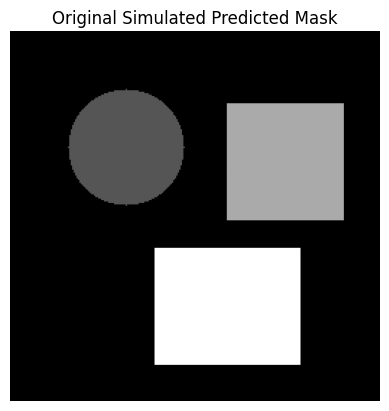

In [15]:
# Create a simulated predicted mask (3-class lookalike)
mask = np.zeros((256, 256), dtype=np.uint8)

# Add fake regions to simulate 3 classes
cv2.circle(mask, (80, 80), 40, 85, -1)      # Class 1 (gray)
cv2.rectangle(mask, (150, 50), (230, 130), 170, -1)  # Class 2 (light gray)
cv2.rectangle(mask, (100, 150), (200, 230), 255, -1)  # Class 3 (white)

plt.imshow(mask, cmap='gray')
plt.title("Original Simulated Predicted Mask")
plt.axis('off')
plt.show()


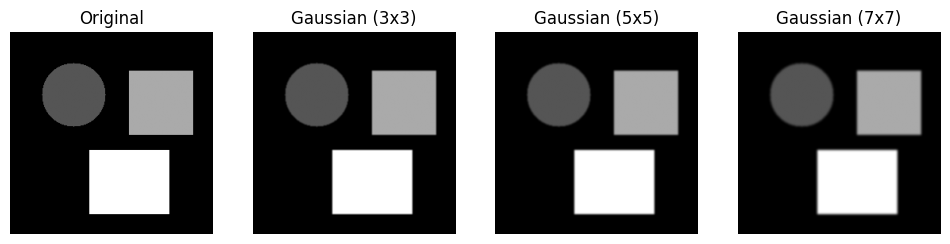

In [16]:
blur_k3 = cv2.GaussianBlur(mask, (3, 3), 0)
blur_k5 = cv2.GaussianBlur(mask, (5, 5), 0)
blur_k7 = cv2.GaussianBlur(mask, (7, 7), 0)

titles = ['Original', 'Gaussian (3x3)', 'Gaussian (5x5)', 'Gaussian (7x7)']
images = [mask, blur_k3, blur_k5, blur_k7]

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


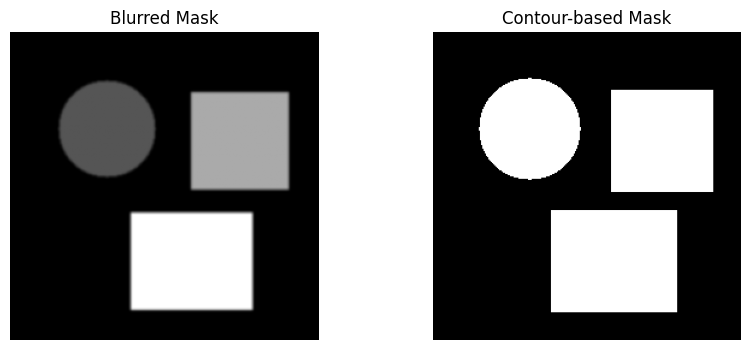

In [17]:
# Choose the best blurred version (5x5) for contour detection
blurred = blur_k5

# Find external contours
contours, hierarchy = cv2.findContours(blurred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a blank mask
contour_mask = np.zeros_like(mask)
cv2.drawContours(contour_mask, contours, -1, 255, thickness=cv2.FILLED)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contour_mask, cmap='gray')
plt.title('Contour-based Mask')
plt.axis('off')
plt.show()


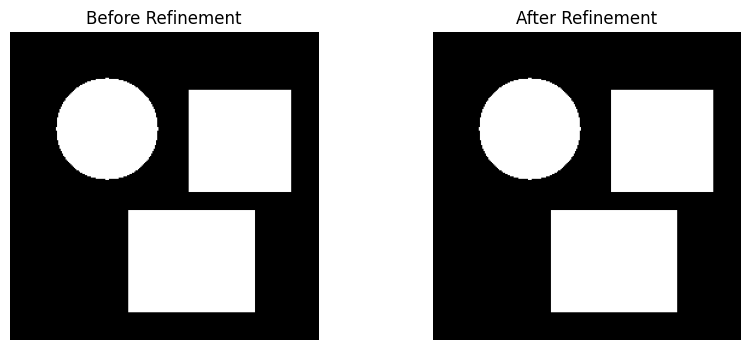

In [18]:
# Apply morphological operations to refine mask
kernel_open = np.ones((3,3), np.uint8)
kernel_close = np.ones((5,5), np.uint8)

refined = cv2.morphologyEx(contour_mask, cv2.MORPH_OPEN, kernel_open)  # remove small noise
refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel_close)     # fill small holes

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(contour_mask, cmap='gray')
plt.title('Before Refinement')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(refined, cmap='gray')
plt.title('After Refinement')
plt.axis('off')
plt.show()


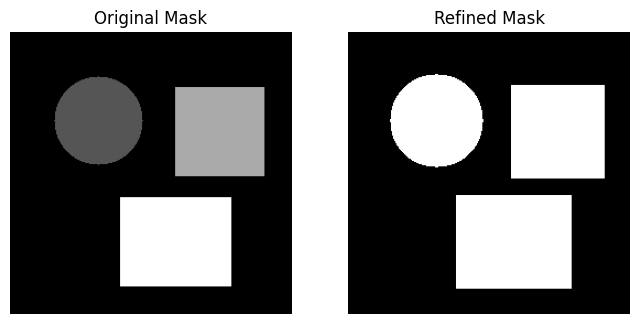

In [20]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title('Original Mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(refined, cmap='gray')
plt.title('Refined Mask')
plt.axis('off')
plt.show()
